# Cap 4 — GPT do Zero: Aula Prática Visual

Notebook **complementar** ao `ch04.ipynb` do Sebastian Raschka. Aqui a gente **não reescreve** o modelo: importa o
`GPTModel` do próprio `gpt.py` do autor e usa **hooks** do PyTorch para *ver* os tensores fluindo,
contar parâmetros e visualizar as peças-chave do capítulo.

**Como usar na aula:** rode célula por célula. Cada seção tem uma pergunta pros alunos antes do output.

> Rode a partir da pasta `ch04/01_main-chapter-code/` (onde está o `gpt.py`).

In [1]:
import sys, os
# garante que o gpt.py do autor está no path (ajuste se rodar de outra pasta)
sys.path.insert(0, os.path.abspath("."))

import torch, torch.nn as nn
import tiktoken
import matplotlib.pyplot as plt

from gpt import GPTModel, generate_text_simple, GELU, LayerNorm, TransformerBlock, FeedForward

GPT_CONFIG_124M = {
    "vocab_size": 50257, "context_length": 1024, "emb_dim": 768,
    "n_heads": 12, "n_layers": 12, "drop_rate": 0.1, "qkv_bias": False,
}
torch.manual_seed(123)
print("PyTorch:", torch.__version__)
print("Importado do gpt.py do autor:", GPTModel.__module__)

PyTorch: 2.14.0
Importado do gpt.py do autor: gpt


## 1. Quantos parâmetros? De onde vêm?

**Pergunta pra turma:** o modelo se chama GPT-**124M**. Você aposta que ele tem 124 milhões de parâmetros?

In [2]:
model = GPTModel(GPT_CONFIG_124M)

total = sum(p.numel() for p in model.parameters())
tok = model.tok_emb.weight.numel()
head = model.out_head.weight.numel()

print(f"Total de parâmetros:        {total:,}")
print(f"Token embedding (tok_emb):  {tok:,}")
print(f"Output head (out_head):     {head:,}")
print(f"Sem a out_head (tie):       {total - head:,}   <- é daqui que vem 'GPT-124M'")
print(f"Tamanho em float32:         {total*4/1024/1024:.1f} MB")

Total de parâmetros:        163,009,536
Token embedding (tok_emb):  38,597,376
Output head (out_head):     38,597,376
Sem a out_head (tie):       124,412,160   <- é daqui que vem 'GPT-124M'
Tamanho em float32:         621.8 MB


**Resposta:** são **163M** reais. O nome "124M" vem do *weight tying* do GPT-2 original: `tok_emb` e `out_head`
têm o mesmo tamanho (768×50257) e no GPT-2 compartilham os pesos, então contam uma vez só. O autor deixa
os dois separados no código do capítulo — por isso `sum(numel)` dá 163M.

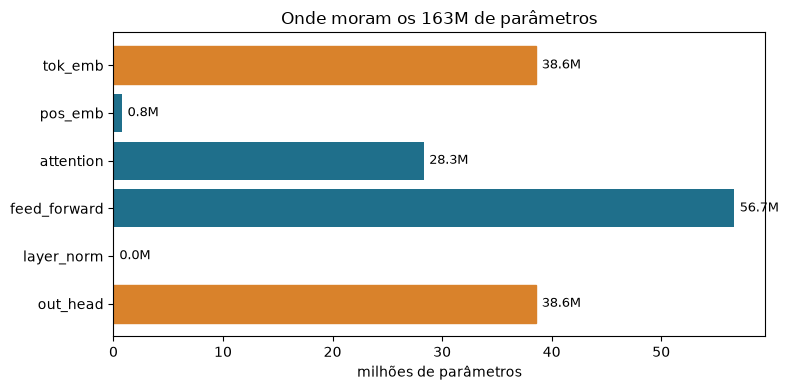

In [3]:
# Distribuição dos parâmetros por tipo de camada
buckets = {"tok_emb":0, "pos_emb":0, "attention":0, "feed_forward":0, "layer_norm":0, "out_head":0}
for name, p in model.named_parameters():
    n = p.numel()
    if   name.startswith("tok_emb"):        buckets["tok_emb"] += n
    elif name.startswith("pos_emb"):        buckets["pos_emb"] += n
    elif ".att." in name:                   buckets["attention"] += n
    elif ".ff." in name:                    buckets["feed_forward"] += n
    elif "norm" in name:                    buckets["layer_norm"] += n
    elif name.startswith("out_head"):       buckets["out_head"] += n

labels = list(buckets); vals = [buckets[k]/1e6 for k in labels]
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(labels, vals, color="#1f6f8b")
bars[0].set_color("#d9822b"); bars[-1].set_color("#d9822b")  # os dois "gêmeos" do weight tying
ax.set_xlabel("milhões de parâmetros"); ax.set_title("Onde moram os 163M de parâmetros")
for b,v in zip(bars, vals): ax.text(v+0.5, b.get_y()+b.get_height()/2, f"{v:.1f}M", va="center", fontsize=9)
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 1.5 A família GPT-2 — e se a gente crescer o modelo?

O código do cap 4 é o GPT-2 **Small**. Mudando só três números — `emb_dim`, `n_layers` e `n_heads` — chegamos
nos irmãos maiores (é o exercício 4.1 do livro). Contamos os parâmetros por uma **fórmula fechada** (rápido e sem
precisar instanciar o XL de 1,5 bi na RAM da sala).

In [4]:
VOCAB, CTX = 50257, 768  # nota: ctx do pos_emb; usamos 1024 no forward mas a tabela é 1024
CTX = 1024

def count_params(emb, layers, tie=False):
    """Fórmula fechada para ESTA arquitetura (qkv_bias=False)."""
    tok  = VOCAB * emb            # token embedding
    pos  = CTX * emb              # positional embedding
    per_block = 12 * emb**2 + 10 * emb   # MHA (4emb²+emb) + FFN (8emb²+5emb) + 2·LayerNorm (4emb)
    final_norm = 2 * emb
    head = emb * VOCAB            # out_head
    total = tok + pos + layers * per_block + final_norm + head
    return total - (head if tie else 0)   # tie=True simula o weight tying do GPT-2

# valida a fórmula contra o modelo real que instanciamos na seção 1
assert count_params(768, 12) == total, "fórmula não bate com o modelo instanciado!"
print("fórmula validada contra o GPTModel real ✓\n")

FAMILY = {
    "Small":  dict(emb=768,  layers=12, heads=12),
    "Medium": dict(emb=1024, layers=24, heads=16),
    "Large":  dict(emb=1280, layers=36, heads=20),
    "XL":     dict(emb=1600, layers=48, heads=25),
}

print(f"{'modelo':<8}{'emb':>6}{'layers':>8}{'heads':>7}{'params (163M-style)':>22}{'com weight tying':>20}")
print("-"*72)
for name, c in FAMILY.items():
    untied = count_params(c["emb"], c["layers"])
    tied   = count_params(c["emb"], c["layers"], tie=True)
    print(f"{name:<8}{c['emb']:>6}{c['layers']:>8}{c['heads']:>7}{untied/1e6:>19.1f}M{tied/1e6:>18.1f}M")

fórmula validada contra o GPTModel real ✓

modelo     emb  layers  heads   params (163M-style)    com weight tying
------------------------------------------------------------------------
Small      768      12     12              163.0M             124.4M
Medium    1024      24     16              406.2M             354.7M
Large     1280      36     20              838.2M             773.9M
XL        1600      48     25             1637.8M            1557.4M


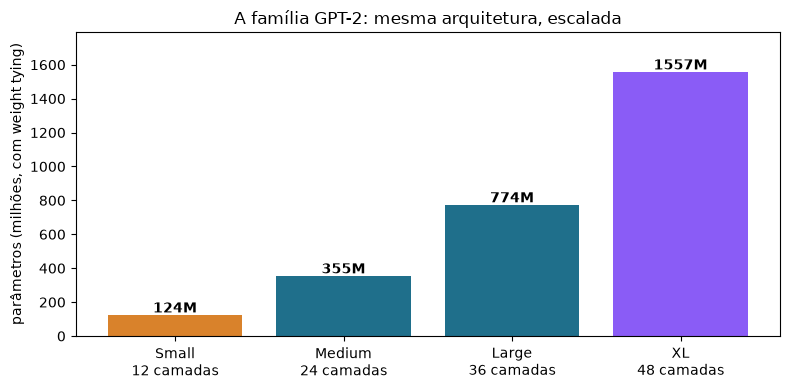

In [5]:
names = list(FAMILY)
tied_vals = [count_params(FAMILY[n]["emb"], FAMILY[n]["layers"], tie=True)/1e6 for n in names]

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar([f"{n}\n{FAMILY[n]['layers']} camadas" for n in names], tied_vals,
              color=["#d9822b","#1f6f8b","#1f6f8b","#8a5cf6"])
ax.set_ylabel("parâmetros (milhões, com weight tying)")
ax.set_title("A família GPT-2: mesma arquitetura, escalada")
for b,v in zip(bars, tied_vals):
    ax.text(b.get_x()+b.get_width()/2, v+15, f"{v:.0f}M", ha="center", fontsize=10, fontweight="bold")
ax.margins(y=.15); plt.tight_layout(); plt.show()

Repare: a arquitetura é **exatamente a mesma** que você acabou de codar — só escala `emb_dim` e empilha
mais blocos. É por isso que o cap 4 se chama "from scratch": você constrói o GPT-2 Small e o resto é o mesmo
Lego, só que maior. O crescimento é **quadrático** em `emb_dim` (por causa dos `12·emb²` por bloco).

## 2. GELU vs ReLU — a ativação do FeedForward (seção 4.3)

**Pergunta:** por que os transformers usam GELU e não o ReLU clássico?

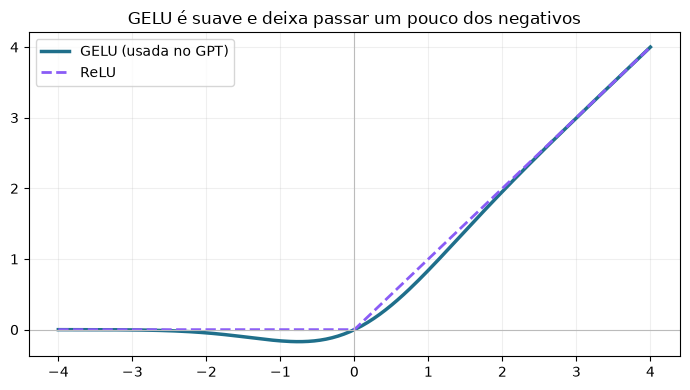

In [6]:
x = torch.linspace(-4, 4, 200)
gelu, relu = GELU(), nn.ReLU()
plt.figure(figsize=(7,4))
plt.plot(x, gelu(x), label="GELU (usada no GPT)", color="#1f6f8b", lw=2.5)
plt.plot(x, relu(x), label="ReLU", color="#8a5cf6", ls="--", lw=2)
plt.axhline(0, color="#bbb", lw=.8); plt.axvline(0, color="#bbb", lw=.8)
plt.legend(); plt.title("GELU é suave e deixa passar um pouco dos negativos"); plt.grid(alpha=.2)
plt.tight_layout(); plt.show()

**Resposta:** GELU é suave (derivável em todo ponto) e não zera bruscamente os negativos, o que ajuda
o gradiente a fluir melhor no treino. É a curva laranja do diagrama interativo da aula.

## 3. Ver os shapes fluindo (o coração da aula)

Vamos registrar **hooks** em cada submódulo e passar `"Hello, I am"` pelo modelo. Cada linha mostra
o shape do tensor **saindo** daquela camada — exatamente o que o diagrama interativo mostra, mas ao vivo.

In [7]:
tokenizer = tiktoken.get_encoding("gpt2")
ids = tokenizer.encode("Hello, I am")
x = torch.tensor(ids).unsqueeze(0)
print("Texto:  'Hello, I am'")
print("Tokens:", ids, " -> shape de entrada:", tuple(x.shape))

logs = []
def hook(module, inp, out):
    if isinstance(out, torch.Tensor):
        logs.append((module.__class__.__name__, tuple(out.shape)))

handles = []
for name, m in model.named_modules():
    # só as peças didáticas do capítulo (evita listar cada Linear interno)
    if isinstance(m, (nn.Embedding, LayerNorm, FeedForward, TransformerBlock)) or name == "out_head":
        handles.append(m.register_forward_hook(hook))

model.eval()
with torch.no_grad():
    _ = model(x)
for h in handles: h.remove()

print("\n{:<22}{}".format("camada", "shape de saída"))
print("-"*45)
for cls, shp in logs:
    print("{:<22}{}".format(cls, shp))

Texto:  'Hello, I am'
Tokens: [15496, 11, 314, 716]  -> shape de entrada: (1, 4)

camada                shape de saída
---------------------------------------------
Embedding             (1, 4, 768)
Embedding             (4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           (1, 4, 768)
TransformerBlock      (1, 4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           (1, 4, 768)
TransformerBlock      (1, 4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           (1, 4, 768)
TransformerBlock      (1, 4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           (1, 4, 768)
TransformerBlock      (1, 4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           (1, 4, 768)
TransformerBlock      (1, 4, 768)
LayerNorm             (1, 4, 768)
LayerNorm             (1, 4, 768)
FeedForward           

Repare: **do token embedding até a última LayerNorm o shape nunca muda** — fica `(1, 4, 768)`.
É isso que permite empilhar 12 blocos idênticos. Só a `out_head` no final muda para `(1, 4, 50257)`
= um logit por palavra do vocabulário.

## 4. Gerar texto (seção 4.7)

Modelo **não treinado** → saída é "salada de palavras". O ponto aqui é o **mecanismo** de geração
autorregressiva, não a qualidade. É o gancho perfeito para o cap 5 (pré-treino).

In [8]:
out = generate_text_simple(model, x, max_new_tokens=10, context_size=GPT_CONFIG_124M["context_length"])
print("IDs gerados:", out.squeeze(0).tolist())
print("Texto:      ", tokenizer.decode(out.squeeze(0).tolist()))

IDs gerados: [15496, 11, 314, 716, 27018, 24086, 47843, 30961, 42348, 7267, 49706, 43231, 47062, 34657]
Texto:       Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous


**Deixa a turma pensar:** o texto é aleatório porque os pesos são aleatórios. O `generate_text_simple`
pega o logit do último token, faz `argmax` (greedy) e concatena — repetindo `max_new_tokens` vezes.
No cap 5 esse mesmo modelo aprende e a saída passa a fazer sentido.

---
### Exercícios rápidos (para os alunos)
1. Troque `n_layers` para 24 e `emb_dim` para 1024 — quantos parâmetros dá? (é o GPT-2 medium/large)
2. Desligue o *weight tying* mentalmente: por que amarrar `tok_emb` e `out_head` economiza 38,6M de params?
3. Rode `generate_text_simple` com `max_new_tokens=1` e confirme na mão o `argmax` do último logit.